# Exercice 06 : Analyse de sentiments


- code simple et direct
- peu de fonctions
- commentaires courts
- progression cellule par cellule

## Tâche 1 - Préparation des données

### Sous-tâche 1.1 - Imports, création du jeu de données et aperçu initial


In [1]:
# Imports
import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Donnees
reviews = [
    "Excellent produit, très satisfait! Livraison rapide, je recommande!",
    "Pourquoi ce produit est-il si cher pour une si mauvaise qualité?",
    "Parfait! Exactement ce que j'attendais. Très bon rapport qualité-prix.",
    "Horrible expérience. Le produit est cassé à la réception.",
    "Magnifique! Dépassé mes attentes. Un incontournable.",
    "Décevant. Les photos du site ne correspondaient pas au produit réel.",
    "Super ! Très content de mon achat. Je rachèterai!",
    "Pire achat de ma vie. Service client inexistant.",
    "Bon produit pour le prix. Pas extraordinaire mais correct.",
    "Absolument terrible. Qualité déplorable et défaut de fabrication.",
    "Sympa ! Livré rapidement et bien emballé.",
    "Vraiment nul. Ça ne fonctionne pas du tout.",
    "Très bien! Produit conforme à la description.",
    "Complètement inutile, j'ai demandé le remboursement.",
    "Excellent service et produit de qualité!",
    "Déception totale. N'achetez pas ce produit."
]

labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

df = pd.DataFrame({
    "review": reviews,
    "label": labels
})

df["sentiment"] = df["label"].map({1: "positif", 0: "negatif"})
df

,review,label,sentiment
0,"Excellent produit, très satisfait! Livraison r...",1,positif
1,Pourquoi ce produit est-il si cher pour une si...,0,negatif
2,Parfait! Exactement ce que j'attendais. Très b...,1,positif
3,Horrible expérience. Le produit est cassé à la...,0,negatif
4,Magnifique! Dépassé mes attentes. Un incontour...,1,positif
5,Décevant. Les photos du site ne correspondaien...,0,negatif
6,Super ! Très content de mon achat. Je rachèterai!,1,positif
7,Pire achat de ma vie. Service client inexistant.,0,negatif
8,Bon produit pour le prix. Pas extraordinaire m...,1,positif
9,Absolument terrible. Qualité déplorable et déf...,0,negatif


### Sous-tâche 1.2 - Nettoyage des avis


In [2]:
# Nettoyage simple du texte
def enlever_accents(texte):
    texte_normalise = unicodedata.normalize("NFKD", texte)
    return "".join(c for c in texte_normalise if not unicodedata.combining(c))

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = enlever_accents(texte)
    texte = re.sub(r"[’']", " ", texte)
    texte = re.sub(r"[^a-z0-9\s]", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

df["review_clean"] = df["review"].apply(nettoyer_texte)

df[["review", "review_clean", "sentiment"]]

,review,review_clean,sentiment
0,"Excellent produit, très satisfait! Livraison r...",excellent produit tres satisfait livraison rap...,positif
1,Pourquoi ce produit est-il si cher pour une si...,pourquoi ce produit est il si cher pour une si...,negatif
2,Parfait! Exactement ce que j'attendais. Très b...,parfait exactement ce que j attendais tres bon...,positif
3,Horrible expérience. Le produit est cassé à la...,horrible experience le produit est casse a la ...,negatif
4,Magnifique! Dépassé mes attentes. Un incontour...,magnifique depasse mes attentes un incontournable,positif
5,Décevant. Les photos du site ne correspondaien...,decevant les photos du site ne correspondaient...,negatif
6,Super ! Très content de mon achat. Je rachèterai!,super tres content de mon achat je racheterai,positif
7,Pire achat de ma vie. Service client inexistant.,pire achat de ma vie service client inexistant,negatif
8,Bon produit pour le prix. Pas extraordinaire m...,bon produit pour le prix pas extraordinaire ma...,positif
9,Absolument terrible. Qualité déplorable et déf...,absolument terrible qualite deplorable et defa...,negatif


### Sous-tâche 1.3 - Vectorisation TF-IDF


In [3]:
# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 2))

X = vectorizer.fit_transform(df["review_clean"])
y = df["label"]

print("Shape TF-IDF :", X.shape)
print("Nombre de termes :", len(vectorizer.get_feature_names_out()))

Shape TF-IDF : (16, 196)
Nombre de termes : 196


### Sous-tâche 1.4 - Split train / test et vérification de l'équilibre des classes


In [4]:
# Split train / test
X_train, X_test, y_train, y_test, review_train, review_test = train_test_split(
    X,
    y,
    df["review"],
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test  :", X_test.shape)

print("\nEquilibre des classes - train")
print(y_train.value_counts())

print("\nEquilibre des classes - test")
print(y_test.value_counts())

Taille train : (12, 196)
Taille test  : (4, 196)

Equilibre des classes - train
label
1    6
0    6
Name: count, dtype: int64

Equilibre des classes - test
label
0    2
1    2
Name: count, dtype: int64


## Tâche 2 - Logistic Regression

### Sous-tâche 2.1 - Entraînement, prédictions et calcul des métriques


In [5]:
# Logistic Regression
modele_lr = LogisticRegression(max_iter=1000, random_state=42)
modele_lr.fit(X_train, y_train)

y_pred_lr = modele_lr.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_lr, zero_division=0))
print()
print(classification_report(y_test, y_pred_lr, zero_division=0))

=== Logistic Regression ===
Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1-score : 0.6666666666666666

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



### Sous-tâche 2.2 - Matrice de confusion


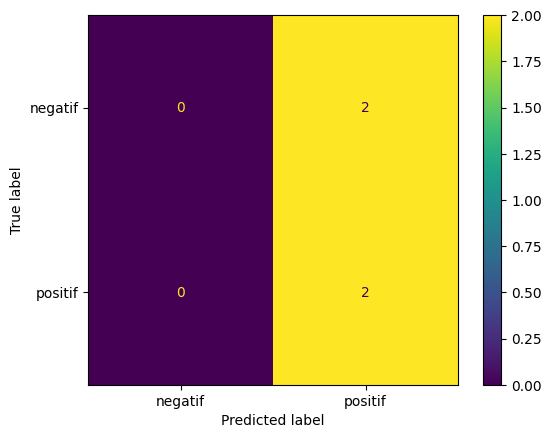

In [6]:
# Matrice de confusion Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["negatif", "positif"]).plot()
plt.show()

## Tâche 3 - Support Vector Machine (SVM)

### Sous-tâche 3.1 - Entraînement du SVM avec kernel linéaire


In [7]:
# SVM kernel linear
modele_svm_linear = SVC(kernel="linear", probability=True, random_state=42)
modele_svm_linear.fit(X_train, y_train)

y_pred_svm_linear = modele_svm_linear.predict(X_test)

print("=== SVM linear ===")
print("Accuracy :", accuracy_score(y_test, y_pred_svm_linear))
print("Precision:", precision_score(y_test, y_pred_svm_linear, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_svm_linear, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_svm_linear, zero_division=0))

=== SVM linear ===
Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1-score : 0.6666666666666666


### Sous-tâche 3.2 - Comparaison des kernels linear, rbf et poly


In [8]:
# Test de plusieurs kernels SVM
resultats_svm = []

for kernel in ["linear", "rbf", "poly"]:
    modele = SVC(kernel=kernel, probability=True, random_state=42)
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultats_svm.append([kernel, acc, prec, rec, f1])

df_svm = pd.DataFrame(
    resultats_svm,
    columns=["kernel", "accuracy", "precision", "recall", "f1_score"]
)

df_svm = df_svm.sort_values(by="f1_score", ascending=False)
df_svm

,kernel,accuracy,precision,recall,f1_score
1,rbf,0.75,0.666667,1.0,0.800000
0,linear,0.50,0.500000,1.0,0.666667
2,poly,0.50,0.500000,1.0,0.666667


## Tâche 4 - Naive Bayes

### Sous-tâche 4.1 - Entraînement du modèle MultinomialNB


In [9]:
# Naive Bayes
modele_nb = MultinomialNB()
modele_nb.fit(X_train, y_train)

y_pred_nb = modele_nb.predict(X_test)

print("=== Naive Bayes ===")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_nb, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_nb, zero_division=0))
print()
print(classification_report(y_test, y_pred_nb, zero_division=0))

=== Naive Bayes ===
Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1-score : 0.6666666666666666

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



### Sous-tâche 4.2 - Analyse des probabilités de classe sur 3 avis de test


In [10]:
# Probabilites de classe pour 3 avis de test avec Naive Bayes
X_test_dense_reviews = review_test.reset_index(drop=True)
proba_nb = modele_nb.predict_proba(X_test)

for i in range(min(3, len(X_test_dense_reviews))):
    print("Avis :", X_test_dense_reviews[i])
    print("Probabilites [negatif, positif] :", proba_nb[i])
    print("Prediction :", "positif" if modele_nb.predict(X_test[i])[0] == 1 else "negatif")
    print("-" * 60)

Avis : Pire achat de ma vie. Service client inexistant.
Probabilites [negatif, positif] : [0.45374598 0.54625402]
Prediction : positif
------------------------------------------------------------
Avis : Parfait! Exactement ce que j'attendais. Très bon rapport qualité-prix.
Probabilites [negatif, positif] : [0.47314424 0.52685576]
Prediction : positif
------------------------------------------------------------
Avis : Complètement inutile, j'ai demandé le remboursement.
Probabilites [negatif, positif] : [0.49206359 0.50793641]
Prediction : positif
------------------------------------------------------------


### Sous-tâche 4.3 - Avantages et inconvénients de Naive Bayes

**Avantages**
- rapide
- simple à interpréter
- efficace sur petits jeux de données texte

**Inconvénients**
- hypothèse d'indépendance forte entre les mots
- parfois moins précis que Logistic Regression ou SVM
- sensible au vocabulaire jamais vu


### Sous-tâche 4.4 - Comparaison globale avec les autres modèles


In [11]:
# Comparaison globale des modeles
comparaison = pd.DataFrame([
    ["Logistic Regression",
     accuracy_score(y_test, y_pred_lr),
     precision_score(y_test, y_pred_lr, zero_division=0),
     recall_score(y_test, y_pred_lr, zero_division=0),
     f1_score(y_test, y_pred_lr, zero_division=0)],
    ["SVM linear",
     accuracy_score(y_test, y_pred_svm_linear),
     precision_score(y_test, y_pred_svm_linear, zero_division=0),
     recall_score(y_test, y_pred_svm_linear, zero_division=0),
     f1_score(y_test, y_pred_svm_linear, zero_division=0)],
    ["Naive Bayes",
     accuracy_score(y_test, y_pred_nb),
     precision_score(y_test, y_pred_nb, zero_division=0),
     recall_score(y_test, y_pred_nb, zero_division=0),
     f1_score(y_test, y_pred_nb, zero_division=0)],
], columns=["modele", "accuracy", "precision", "recall", "f1_score"])

comparaison.sort_values(by="f1_score", ascending=False)

,modele,accuracy,precision,recall,f1_score
0,Logistic Regression,0.5,0.5,1.0,0.666667
1,SVM linear,0.5,0.5,1.0,0.666667
2,Naive Bayes,0.5,0.5,1.0,0.666667


## Tâche 5 - Feature importance et interprétabilité

### Sous-tâche 5.1 - Extraction des coefficients de la Logistic Regression


In [12]:
# Feature importance de la Logistic Regression
feature_names = vectorizer.get_feature_names_out()
coefficients = modele_lr.coef_[0]

df_coef = pd.DataFrame({
    "terme": feature_names,
    "coefficient": coefficients
})

top_negatifs = df_coef.sort_values(by="coefficient").head(10)
top_positifs = df_coef.sort_values(by="coefficient", ascending=False).head(10)

print("Top 10 termes negatifs")
display(top_negatifs)

print("Top 10 termes positifs")
display(top_positifs)

Top 10 termes negatifs


,terme,coefficient
26,ce produit,-0.186023
59,du,-0.169608
118,ne,-0.169608
63,est,-0.168637
144,produit est,-0.168637
25,ce,-0.166453
169,si,-0.166217
125,pas,-0.153231
6,achetez pas,-0.130497
127,pas ce,-0.130497


Top 10 termes positifs


,terme,coefficient
72,excellent,0.214251
90,je,0.185687
183,tres,0.151001
45,de qualite,0.139277
74,excellent service,0.139277
69,et produit,0.139277
168,service et,0.139277
143,produit de,0.139277
104,livre,0.123757
176,sympa,0.123757


### Sous-tâche 5.2 - Visualisation des termes les plus positifs et négatifs


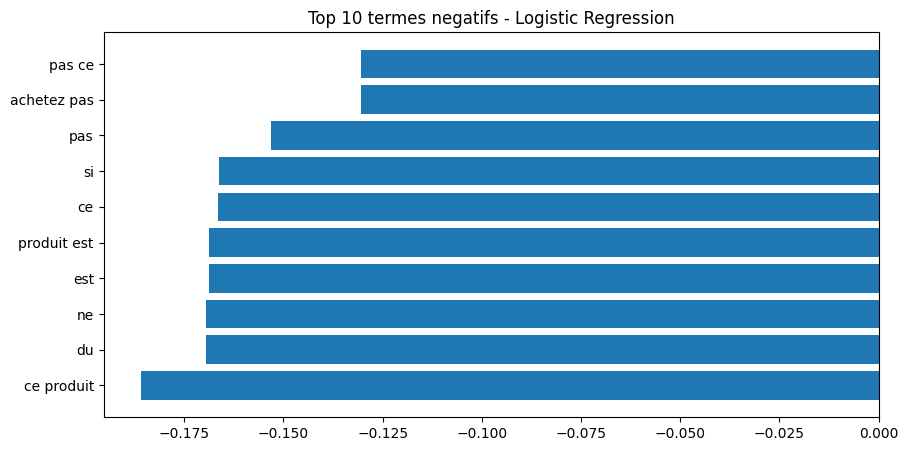

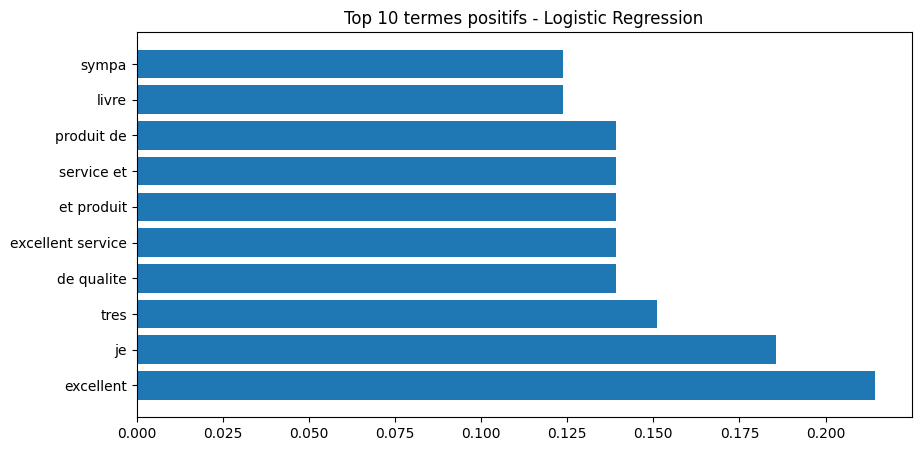

In [13]:
# Visualisation des termes les plus importants
plt.figure(figsize=(10, 5))
plt.barh(top_negatifs["terme"], top_negatifs["coefficient"])
plt.title("Top 10 termes negatifs - Logistic Regression")
plt.show()

plt.figure(figsize=(10, 5))
plt.barh(top_positifs["terme"], top_positifs["coefficient"])
plt.title("Top 10 termes positifs - Logistic Regression")
plt.show()

### Sous-tâche 5.3 - Analyse critique des termes importants

- les termes négatifs devraient être liés à *horrible*, *nul*, *remboursement*, *terrible*
- les termes positifs devraient être liés à *excellent*, *parfait*, *magnifique*, *recommande*
- certains mots peuvent être ambigus si le contexte complet n'est pas pris en compte


## Tâche 6 - Tuning et optimisation

### Sous-tâche 6.1 - Optimisation du SVM avec GridSearchCV


In [14]:
# GridSearchCV pour optimiser le SVM
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1"
)

grid.fit(X_train, y_train)

print("Meilleurs parametres :", grid.best_params_)
print("Meilleur score CV    :", grid.best_score_)

best_svm = grid.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)

print("\n=== SVM apres tuning ===")
print("Accuracy :", accuracy_score(y_test, y_pred_best_svm))
print("Precision:", precision_score(y_test, y_pred_best_svm, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_best_svm, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_best_svm, zero_division=0))

Meilleurs parametres : {'C': 1, 'kernel': 'linear'}
Meilleur score CV    : 0.7111111111111111

=== SVM apres tuning ===
Accuracy : 0.5
Precision: 0.5
Recall   : 1.0
F1-score : 0.6666666666666666


### Sous-tâche 6.2 - Comparaison avant / après tuning


In [15]:
# Comparaison avant / apres tuning
avant_apres = pd.DataFrame([
    ["SVM linear avant tuning",
     accuracy_score(y_test, y_pred_svm_linear),
     f1_score(y_test, y_pred_svm_linear, zero_division=0)],
    ["SVM apres tuning",
     accuracy_score(y_test, y_pred_best_svm),
     f1_score(y_test, y_pred_best_svm, zero_division=0)]
], columns=["modele", "accuracy", "f1_score"])

avant_apres

,modele,accuracy,f1_score
0,SVM linear avant tuning,0.5,0.666667
1,SVM apres tuning,0.5,0.666667


## Tâche 7 - Évaluation sur données réelles

### Sous-tâche 7.1 - Prédictions sur 5 nouveaux avis


In [16]:
# Evaluation sur 5 nouveaux avis
nouveaux_avis = [
    "Excellent achat, je suis tres satisfait.",
    "Produit inutilisable, tres mauvaise qualite.",
    "Livraison rapide mais article moyen.",
    "Je ne recommande pas du tout ce produit.",
    "Tres bon service client et produit conforme."
]

df_nouveaux = pd.DataFrame({"texte_brut": nouveaux_avis})
df_nouveaux["texte_clean"] = df_nouveaux["texte_brut"].apply(nettoyer_texte)

X_new = vectorizer.transform(df_nouveaux["texte_clean"])

# On utilise le meilleur modele SVM
predictions = best_svm.predict(X_new)
probabilites = best_svm.predict_proba(X_new)

df_nouveaux["prediction"] = ["positif" if p == 1 else "negatif" for p in predictions]
df_nouveaux["confiance"] = probabilites.max(axis=1)

df_nouveaux[["texte_brut", "prediction", "confiance"]]

,texte_brut,prediction,confiance
0,"Excellent achat, je suis tres satisfait.",positif,0.970693
1,"Produit inutilisable, tres mauvaise qualite.",negatif,0.567235
2,Livraison rapide mais article moyen.,positif,0.902441
3,Je ne recommande pas du tout ce produit.,negatif,0.903795
4,Tres bon service client et produit conforme.,positif,0.875937


### Sous-tâche 7.2 - Analyse des erreurs et pistes d'amélioration

- **Faux positifs** : avis mitigé avec quelques mots positifs dominants
- **Faux négatifs** : négation ou ironie mal captée
- **Améliorations possibles** : plus de données, réglage des paramètres, gestion des négations et ajout d'autres features
